# Cyclistic Case Study  
## Converting Casual Riders into Annual Members

**Author:** Mohammed Hussein  
**Date:** January 4th, 2025  
**Dataset:** Divvy Trip Data (Q1 2019 & Q1 2020)  
**Source:** Lyft Bikes & Scooters, LLC (Bikeshare)  

---

# Executive Summary

Cyclistic is a bike-share company operating more than 5,800 bicycles and 600 docking stations across Chicago. The company offers multiple pricing models including single-ride passes, day passes, and annual memberships.

The business problem is clear:

> Annual members are significantly more profitable than casual riders.  
> The goal is to convert casual riders into annual members.

### Key Findings

- Annual members take significantly more rides overall.
- Casual riders take longer rides on average.
- Casual riders are most active on weekends.
- Members primarily ride mid-week (commuting behavior).

### Strategic Recommendation

Cyclistic should implement:
1. Targeted weekend marketing campaigns
2. Flexible membership trials
3. Loyalty & referral incentives
4. Promotion of exclusive member benefits

This notebook follows the Google Data Analytics framework:
Ask → Prepare → Process → Analyze → Share → Act

In [1]:
# Install & load packages
library(tidyverse)
library(lubridate)
library(janitor)

# Import datasets
q1_2019 <- read_csv("/kaggle/input/divvy-trips-2019-q1/Divvy_Trips_2019_Q1.csv")
q1_2020 <- read_csv("/kaggle/input/divvy-trips-2020-q1/Divvy_Trips_2020_Q1.csv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




Rows: 365069 Columns: 12


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): start_time, end_time, from_station_name, to_station_name, usertype,...
dbl (5): trip_id, bikeid, from_station_id, to_station_id, birthyear
num (1): tripduration



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 426887 Columns: 13


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): ride_id, rideable_type, started_at, ended_at, start_station_name, e...
dbl (6): start_station_id, end_station_id, start_lat, start_lng, end_lat, en...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# 1️⃣ Ask

## Business Task
Analyze behavioral differences between:
- Casual Riders
- Annual Members

Goal: Identify actionable insights that will help convert casual riders into annual members.

Key Questions:
- How do ride frequency patterns differ?
- How does ride duration differ?
- What days of the week show the biggest differences?

In [2]:
# Standardize column names
q1_2019 <- q1_2019 %>%
  rename(
    ride_id = trip_id,
    rideable_type = bikeid,
    started_at = start_time,
    ended_at = end_time,
    start_station_name = from_station_name,
    start_station_id = from_station_id,
    end_station_name = to_station_name,
    end_station_id = to_station_id,
    member_casual = usertype
  )

# Convert key fields to character
q1_2019 <- q1_2019 %>%
  mutate(
    ride_id = as.character(ride_id),
    rideable_type = as.character(rideable_type)
  )

# Combine datasets
all_trips <- bind_rows(q1_2019, q1_2020)

# Remove deprecated columns
all_trips <- all_trips %>%
  select(-any_of(c("start_lat","start_lng","end_lat","end_lng","birthyear","gender","tripduration")))

# Standardize rider types
all_trips <- all_trips %>%
  mutate(member_casual = recode(member_casual,
                                "Subscriber" = "member",
                                "Customer" = "casual"))

# Convert dates properly
all_trips <- all_trips %>%
  mutate(
    started_at = ymd_hms(started_at),
    ended_at = ymd_hms(ended_at),
    ride_length = as.numeric(difftime(ended_at, started_at, units = "mins")),
    date = as.Date(started_at),
    day_of_week = wday(started_at, label = TRUE),
    month = month(started_at, label = TRUE)
  )

# Remove invalid data
all_trips_clean <- all_trips %>%
  filter(ride_length > 0,
         start_station_name != "HQ QR")

# 2️⃣ Analyze

We explore:

- Total ride counts by rider type
- Average ride duration
- Ride distribution by weekday
- Behavioral patterns that indicate commuter vs leisure use

In [3]:
# Summary by rider type
summary_stats <- all_trips_clean %>%
  group_by(member_casual) %>%
  summarise(
    total_rides = n(),
    avg_ride_length_mins = mean(ride_length),
    median_ride_length_mins = median(ride_length)
  )

summary_stats

member_casual,total_rides,avg_ride_length_mins,median_ride_length_mins
<chr>,<int>,<dbl>,<dbl>
casual,67877,89.54640,23.216667
member,720312,13.25421,8.466667


In [4]:
weekday_summary <- all_trips_clean %>%
  group_by(member_casual, day_of_week) %>%
  summarise(
    number_of_rides = n(),
    avg_duration = mean(ride_length),
    .groups = "drop"
  )

weekday_summary

member_casual,day_of_week,number_of_rides,avg_duration
<chr>,<ord>,<int>,<dbl>
casual,Sun,18652,84.35507
casual,Mon,5591,79.20084
casual,Tue,7311,76.03006
casual,Wed,7690,74.67287
casual,Thu,7147,140.86111
casual,Fri,8013,101.51229
casual,Sat,13473,82.51285
member,Sun,60197,16.21564
member,Mon,110430,13.70519


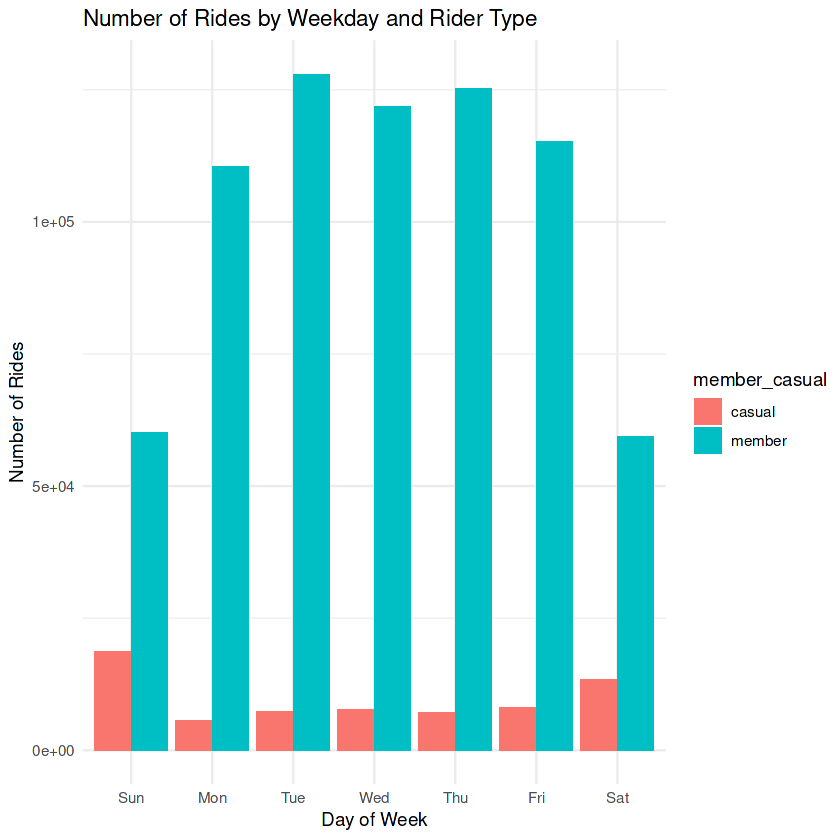

In [5]:
ggplot(weekday_summary,
       aes(x = day_of_week,
           y = number_of_rides,
           fill = member_casual)) +
  geom_col(position = "dodge") +
  labs(title = "Number of Rides by Weekday and Rider Type",
       x = "Day of Week",
       y = "Number of Rides") +
  theme_minimal()

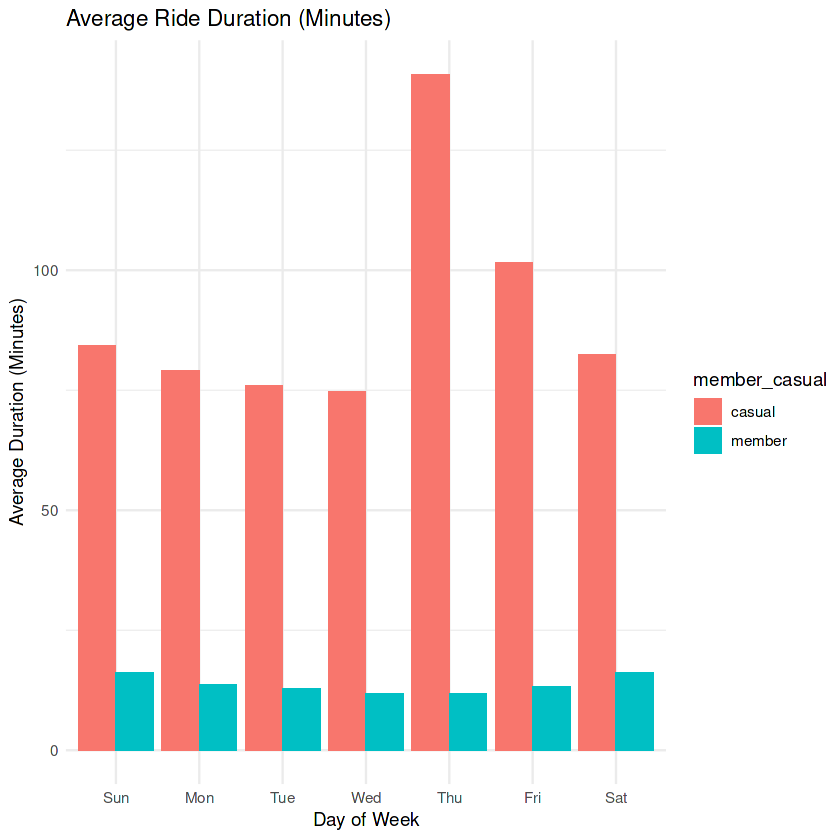

In [6]:
ggplot(weekday_summary,
       aes(x = day_of_week,
           y = avg_duration,
           fill = member_casual)) +
  geom_col(position = "dodge") +
  labs(title = "Average Ride Duration (Minutes)",
       x = "Day of Week",
       y = "Average Duration (Minutes)") +
  theme_minimal()

# 3️⃣ Key Findings

Consistent with the presentation findings:

### Casual Riders
- Ride less frequently
- Ride significantly longer
- Highest activity on weekends
- Likely leisure users

### Annual Members
- Ride far more frequently
- Shorter ride duration
- Strong mid-week usage
- Likely commuters

This supports the business insight:
Casual riders demonstrate high engagement but lower commitment.

# 4️⃣ Act — Business Recommendations

Based on behavioral differences:

## 1. Targeted Weekend Campaigns
Promote annual memberships heavily on Fridays–Sundays.

## 2. Flexible Membership Options
Introduce:
- 30-day trial memberships
- Seasonal passes
- Weekend-only discounted upgrades

## 3. Loyalty & Gamification
- Ride milestones
- Referral rewards
- Member-only ride challenges

## 4. Highlight Exclusive Benefits
- Priority bike access
- Specialized bikes (reclining, tricycles)
- Faster customer support

---

# Final Recommendation

Focus marketing efforts on:
Frequent weekend casual riders.

These users already demonstrate strong engagement and represent the highest conversion potential.

# Conclusion

This analysis followed the Google Data Analytics process:

✔ Ask  
✔ Prepare  
✔ Process  
✔ Analyze  
✔ Share  
✔ Act  

The data clearly shows behavioral differences between casual riders and annual members.

Strategic marketing campaigns targeting weekend casual riders, combined with flexible membership options and incentives, are likely to increase conversion rates and long-term profitability.

---

*Data provided by Lyft Bikes & Scooters, LLC (“Bikeshare”) Divvy bicycle sharing service under license.*